In [2]:
import duckdb
import os

In [3]:
# Mount to Google drive
os.chdir("/content/drive/MyDrive/TLC")

In [ ]:
duckdb.sql("DESCRIBE SELECT * FROM 'yellow_tripdata_2024-01.parquet'")

┌───────────────────────┬─────────────┬─────────┬─────────┬─────────┬─────────┐
│      column_name      │ column_type │  null   │   key   │ default │  extra  │
│        varchar        │   varchar   │ varchar │ varchar │ varchar │ varchar │
├───────────────────────┼─────────────┼─────────┼─────────┼─────────┼─────────┤
│ VendorID              │ INTEGER     │ YES     │ NULL    │ NULL    │ NULL    │
│ tpep_pickup_datetime  │ TIMESTAMP   │ YES     │ NULL    │ NULL    │ NULL    │
│ tpep_dropoff_datetime │ TIMESTAMP   │ YES     │ NULL    │ NULL    │ NULL    │
│ passenger_count       │ BIGINT      │ YES     │ NULL    │ NULL    │ NULL    │
│ trip_distance         │ DOUBLE      │ YES     │ NULL    │ NULL    │ NULL    │
│ RatecodeID            │ BIGINT      │ YES     │ NULL    │ NULL    │ NULL    │
│ store_and_fwd_flag    │ VARCHAR     │ YES     │ NULL    │ NULL    │ NULL    │
│ PULocationID          │ INTEGER     │ YES     │ NULL    │ NULL    │ NULL    │
│ DOLocationID          │ INTEGER     │ 

In [ ]:
duckdb.sql("""
SELECT
    COUNT(*) AS total_trips,
    ROUND(AVG(trip_distance),2) AS avg_trip_distance,
    ROUND(AVG(fare_amount),2) AS avg_fare,
    ROUND(AVG(tip_amount),2) AS avg_tip
FROM 'yellow_tripdata_2024-01.parquet'
""")

┌─────────────┬───────────────────┬──────────┬─────────┐
│ total_trips │ avg_trip_distance │ avg_fare │ avg_tip │
│    int64    │      double       │  double  │ double  │
├─────────────┼───────────────────┼──────────┼─────────┤
│     2964624 │              3.65 │    18.18 │    3.34 │
└─────────────┴───────────────────┴──────────┴─────────┘

In [ ]:
duckdb.sql("""
SELECT
    payment_type,
    ROUND(AVG(tip_amount),2) AS avg_tip,
    COUNT(*) AS num_trips
FROM 'yellow_tripdata_2024-01.parquet'
GROUP BY payment_type
ORDER BY payment_type
LIMIT 5;
""")


┌──────────────┬─────────┬───────────┐
│ payment_type │ avg_tip │ num_trips │
│    int64     │ double  │   int64   │
├──────────────┼─────────┼───────────┤
│            0 │    1.55 │    140162 │
│            1 │    4.17 │   2319046 │
│            2 │     0.0 │    439191 │
│            3 │    0.01 │     19597 │
│            4 │    0.04 │     46628 │
└──────────────┴─────────┴───────────┘

In [5]:
project_id = 'project-ecfefc8b-dba4-4c63-9b1' #@param{type:"string"}

In [6]:
from google.cloud import bigquery

In [7]:
bq_client = bigquery.Client(project = project_id)

In [8]:
#Read data used by CatBoost
%%bigquery results --project {project_id}
SELECT tip_amount, trip_distance, passenger_count, fare_amount, payment_type, RatecodeID,  PULocationID, DOLocationID, tpep_pickup_datetime, tpep_dropoff_datetime
FROM `project-ecfefc8b-dba4-4c63-9b1.nyc.nyc_January`
WHERE tip_amount >=0 AND fare_amount>0 AND trip_distance>0 AND passenger_count IS NOT NULL AND RatecodeID IS NOT NULL AND payment_type = 1;

Query is running:   0%|          |

Downloading:   0%|          |

In [ ]:
#EXPLAIN SQL result
result = duckdb.sql("""
EXPLAIN ANALYZE SELECT tip_amount, trip_distance, passenger_count, fare_amount, payment_type, RatecodeID,  PULocationID, DOLocationID, tpep_pickup_datetime, tpep_dropoff_datetime
FROM 'yellow_tripdata_2024-01.parquet'
WHERE tip_amount >=0 AND fare_amount>0 AND trip_distance>0 AND passenger_count IS NOT NULL AND RatecodeID IS NOT NULL AND payment_type = 1;
""").fetchone()

# 2. Print the second column (index 1) to see the formatted tree
print(result[1])

┌─────────────────────────────────────┐
│┌───────────────────────────────────┐│
││    Query Profiling Information    ││
│└───────────────────────────────────┘│
└─────────────────────────────────────┘
 EXPLAIN ANALYZE SELECT tip_amount, trip_distance, passenger_count, fare_amount, payment_type, RatecodeID,  PULocationID, DOLocationID, tpep_pickup_datetime, tpep_dropoff_datetime FROM 'yellow_tripdata_2024-01.parquet' WHERE tip_amount >=0 AND fare_amount>0 AND trip_distance>0 AND passenger_count IS NOT NULL AND RatecodeID IS NOT NULL AND payment_type = 1; 
┌────────────────────────────────────────────────┐
│┌──────────────────────────────────────────────┐│
││              Total Time: 0.847s              ││
│└──────────────────────────────────────────────┘│
└────────────────────────────────────────────────┘
┌───────────────────────────┐
│           QUERY           │
└─────────────┬─────────────┘
┌─────────────┴─────────────┐
│      EXPLAIN_ANALYZE      │
│    ────────────────────   │
│    

In [ ]:
results

,tip_amount,trip_distance,passenger_count,fare_amount,payment_type,RatecodeID,PULocationID,DOLocationID,tpep_pickup_datetime,tpep_dropoff_datetime
0,6.90,1.70,2,29.6,1,1,246,170,2024-01-01 00:36:30+00:00,2024-01-01 01:13:53+00:00
1,0.00,23.90,1,120.0,1,5,263,265,2024-01-01 00:42:05+00:00,2024-01-01 01:16:49+00:00
2,2.50,5.88,1,28.9,1,1,4,238,2024-01-01 00:20:11+00:00,2024-01-01 00:42:53+00:00
3,11.25,11.51,1,44.3,1,1,262,171,2024-01-01 00:15:26+00:00,2024-01-01 00:33:57+00:00
4,8.04,5.91,1,35.2,1,1,262,244,2024-01-01 00:27:02+00:00,2024-01-01 01:03:56+00:00
...,...,...,...,...,...,...,...,...,...,...
2298385,15.15,19.23,1,70.0,1,2,132,87,2024-01-31 23:47:52+00:00,2024-02-01 00:36:02+00:00
2298386,16.19,18.79,1,70.0,1,2,132,140,2024-01-31 23:13:40+00:00,2024-01-31 23:46:30+00:00
2298387,7.58,18.99,2,70.0,1,2,132,148,2024-01-31 23:18:41+00:00,2024-02-01 00:01:18+00:00
2298388,7.00,17.54,2,70.0,1,2,132,107,2024-01-31 23:11:50+00:00,2024-02-01 00:01:25+00:00


## Train CatBoost Model

In [ ]:
!pip install catboost

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 97.1/97.1 MB 5.1 MB/s eta 0:00:00


In [ ]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, mean_absolute_error
from catboost import CatBoostRegressor

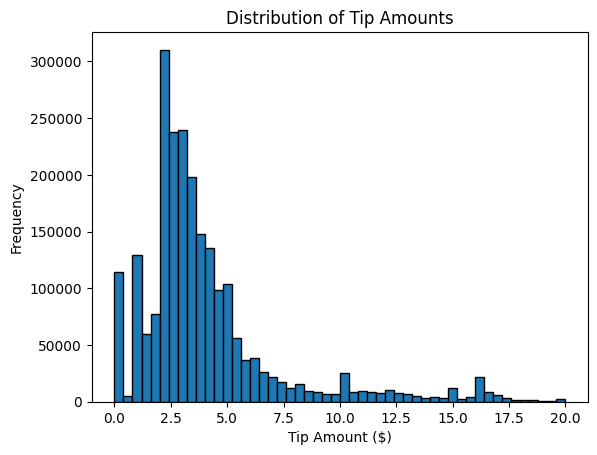

In [ ]:
import matplotlib.pyplot as plt

# Plot a histogram of the tip_amount column

results['tip_amount'].plot(kind='hist', bins=50, range=(0, 20), title='Distribution of Tip Amounts', edgecolor='black')

plt.xlabel('Tip Amount ($)')
plt.ylabel('Frequency')
plt.show()

In [ ]:
# Extract Hour of the Day (0-23)

results['pickup_hour'] = results['tpep_pickup_datetime'].dt.hour
results['dropoff_hour'] = results['tpep_dropoff_datetime'].dt.hour

# Extract Day of the Week (0=Monday, 6=Sunday)

results['day_of_week'] = results['tpep_pickup_datetime'].dt.dayofweek

In [ ]:
results

,tip_amount,trip_distance,passenger_count,fare_amount,payment_type,RatecodeID,PULocationID,DOLocationID,tpep_pickup_datetime,tpep_dropoff_datetime,pickup_hour,day_of_week,dropoff_hour
0,6.90,1.70,2,29.6,1,1,246,170,2024-01-01 00:36:30+00:00,2024-01-01 01:13:53+00:00,0,0,1
1,0.00,23.90,1,120.0,1,5,263,265,2024-01-01 00:42:05+00:00,2024-01-01 01:16:49+00:00,0,0,1
2,2.50,5.88,1,28.9,1,1,4,238,2024-01-01 00:20:11+00:00,2024-01-01 00:42:53+00:00,0,0,0
3,11.25,11.51,1,44.3,1,1,262,171,2024-01-01 00:15:26+00:00,2024-01-01 00:33:57+00:00,0,0,0
4,8.04,5.91,1,35.2,1,1,262,244,2024-01-01 00:27:02+00:00,2024-01-01 01:03:56+00:00,0,0,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...
2298385,15.15,19.23,1,70.0,1,2,132,87,2024-01-31 23:47:52+00:00,2024-02-01 00:36:02+00:00,23,2,0
2298386,16.19,18.79,1,70.0,1,2,132,140,2024-01-31 23:13:40+00:00,2024-01-31 23:46:30+00:00,23,2,23
2298387,7.58,18.99,2,70.0,1,2,132,148,2024-01-31 23:18:41+00:00,2024-02-01 00:01:18+00:00,23,2,0
2298388,7.00,17.54,2,70.0,1,2,132,107,2024-01-31 23:11:50+00:00,2024-02-01 00:01:25+00:00,23,2,0


In [ ]:
X = results.drop(columns=['tip_amount', 'payment_type', 'tpep_pickup_datetime', 'tpep_dropoff_datetime'])
y = results['tip_amount']

In [ ]:
cat_features = ['RatecodeID', 'PULocationID', 'DOLocationID','day_of_week','dropoff_hour','pickup_hour']

In [ ]:
# Split the data at an approximate 70%/25%/5% split for train/test/validation set
X_train, X_temp, y_train, y_temp = train_test_split(X, y, test_size=0.3, random_state=42)

X_val, X_test, y_val, y_test = train_test_split(X_temp, y_temp, test_size=0.8, random_state=42)

print(f"Train size: {len(X_train)} | Val size: {len(X_val)} | Test size: {len(X_test)}\n")

Train size: 1608873 | Val size: 137903 | Test size: 551614



In [ ]:
print("Starting hyperparameter tuning on subsample...")
X_tune = X_train.sample(n=100000, random_state=42)
y_tune = y_train.loc[X_tune.index]

cb_tuner = CatBoostRegressor(cat_features=cat_features, loss_function='RMSE', verbose=0)

# Grid of parameters
param_grid = {
    'iterations': [200, 500],
    'learning_rate': [0.05, 0.1],
    'depth': [6, 8]
}

# CatBoost grid search
grid_search_results = cb_tuner.grid_search(param_grid, X=X_tune, y=y_tune, cv=3, plot=False)
best_params = grid_search_results['params']
print(f"Best Parameters Found: {best_params}\n")

Starting hyperparameter tuning on subsample...

bestTest = 2.183870208
bestIteration = 191

0:	loss: 2.1838702	best: 2.1838702 (0)	total: 23.4s	remaining: 2m 43s

bestTest = 2.168445936
bestIteration = 172

1:	loss: 2.1684459	best: 2.1684459 (1)	total: 45.3s	remaining: 2m 16s

bestTest = 2.17082657
bestIteration = 482

2:	loss: 2.1708266	best: 2.1684459 (1)	total: 1m 44s	remaining: 2m 54s

bestTest = 2.167247733
bestIteration = 233

3:	loss: 2.1672477	best: 2.1672477 (3)	total: 2m 45s	remaining: 2m 45s

bestTest = 2.17962801
bestIteration = 199

4:	loss: 2.1796280	best: 2.1672477 (3)	total: 3m 17s	remaining: 1m 58s

bestTest = 2.178405104
bestIteration = 173

5:	loss: 2.1784051	best: 2.1672477 (3)	total: 3m 54s	remaining: 1m 18s

bestTest = 2.171849984
bestIteration = 414

6:	loss: 2.1718500	best: 2.1672477 (3)	total: 5m 20s	remaining: 45.8s

bestTest = 2.178405104
bestIteration = 173

7:	loss: 2.1784051	best: 2.1672477 (3)	total: 6m 47s	remaining: 0us
Estimating final quality...
Train

In [ ]:
print("Training final model on full dataset...")

# Initialize the model with the best parameters found above
final_model = CatBoostRegressor(
    **best_params,
    cat_features=cat_features,
    loss_function='RMSE',
    eval_metric='RMSE',
    random_seed=42,
    early_stopping_rounds=50 # Prevents overfitting by stopping if validation score doesn't improve
)

# Fit the model
final_model.fit(
    X_train, y_train,
    eval_set=(X_val, y_val),
    verbose=100
)

Training final model on full dataset...
0:	learn: 3.6305659	test: 3.6073538	best: 3.6073538 (0)	total: 3.05s	remaining: 25m 22s
100:	learn: 2.3211880	test: 2.2968104	best: 2.2968104 (100)	total: 3m 22s	remaining: 13m 18s
200:	learn: 2.3071162	test: 2.2935472	best: 2.2933511 (195)	total: 7m 1s	remaining: 10m 26s
Stopped by overfitting detector  (50 iterations wait)

bestTest = 2.292781576
bestIteration = 245

Shrink model to first 246 iterations.


CatBoostRegressor(cat_features=['RatecodeID', 'PULocationID', 'DOLocationID', 'day_of_week', 'dropoff_hour', 'pickup_hour'], depth=6, early_stopping_rounds=50, eval_metric='RMSE', iterations=500, learning_rate=0.1, loss_function='RMSE', random_seed=42)

In [ ]:
#Final evaluation on test dataset
y_pred = final_model.predict(X_test)

rmse = np.sqrt(mean_squared_error(y_test, y_pred))
mae = mean_absolute_error(y_test, y_pred)

print(f"\n--- Final Test Set Performance ---")
print(f"RMSE: ${rmse:.2f}")
print(f"MAE:  ${mae:.2f}")


--- Final Test Set Performance ---
RMSE: $2.33
MAE:  $1.18


In [ ]:
#Feature importance
importances = pd.DataFrame({
    'Feature': final_model.feature_names_,
    'Importance': final_model.feature_importances_
}).sort_values(by='Importance', ascending=False)

print(importances)

           Feature  Importance
2      fare_amount   61.056883
3       RatecodeID   22.952135
0    trip_distance    5.337485
5     DOLocationID    4.552230
4     PULocationID    2.747850
6      pickup_hour    1.299104
7      day_of_week    0.837421
8     dropoff_hour    0.799987
1  passenger_count    0.416904
